# First one 

In [2]:
import tensorflow as tf

In [4]:


from tensorflow.keras import datasets, layers, models
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import MaxPooling2D, Conv2D

In [6]:
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

In [8]:
train_images = train_images / 255.0
test_images = test_images / 255.0

In [10]:
model = models.Sequential([
    # الجزء الأول: استخراج الملامح والميزات من الصور (Feature Extraction)
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax') # 10 كلاسات + softmax
])

/opt/anaconda3/envs/churn_project/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

In [14]:
print("بداية التدريب...")
history = model.fit(train_images, train_labels, 
                    epochs=10, # عدد مرات مرور الداتا على الموديل
                    validation_data=(test_images, test_labels))

بداية التدريب...
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.4466 - loss: 1.5199 - val_accuracy: 0.5371 - val_loss: 1.2998
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.5913 - loss: 1.1548 - val_accuracy: 0.6247 - val_loss: 1.0638
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6492 - loss: 1.0015 - val_accuracy: 0.6670 - val_loss: 0.9457
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6828 - loss: 0.9013 - val_accuracy: 0.6841 - val_loss: 0.9107
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7098 - loss: 0.8290 - val_accuracy: 0.6940 - val_loss: 0.8665
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7308 - loss: 0.7673 - val_accuracy: 0.7083 - val_loss: 0.8353
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7473 - loss: 0.7161 - val_accuracy: 0.6981 - val_loss: 0.8783
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7645 

313/313 - 1s - 2ms/step - accuracy: 0.7174 - loss: 0.8319
دقة الموديل النهائية على بيانات الاختبار: 71.74%


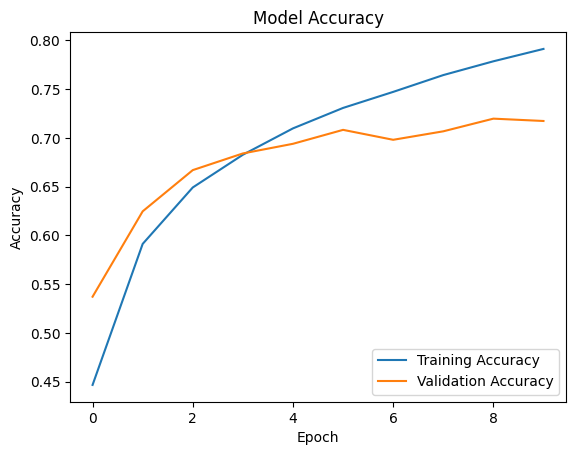

In [16]:
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f"دقة الموديل النهائية على بيانات الاختبار: {test_acc * 100:.2f}%")

# رسم منحنى التعلم
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label = 'Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.title('Model Accuracy')
plt.show()

# Second one 

In [23]:
fashion_mnist = tf.keras.datasets.fashion_mnist

In [25]:
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 1us/step


In [27]:
print(train_labels)

[9 0 0 ... 3 0 5]


In [29]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [31]:
print(train_images.shape)

(60000, 28, 28)


In [33]:
print(test_images.shape)

(10000, 28, 28)


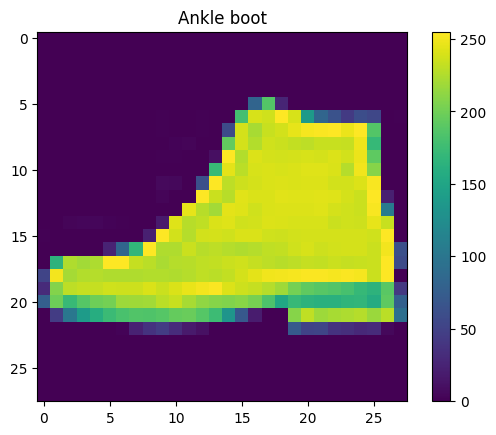

In [35]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(train_images[42])
plt.colorbar()
plt.grid(False)
plt.title(class_names[train_labels[42]])
plt.show()

In [37]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
train_images = train_images/255.0
test_images = test_images/255.0


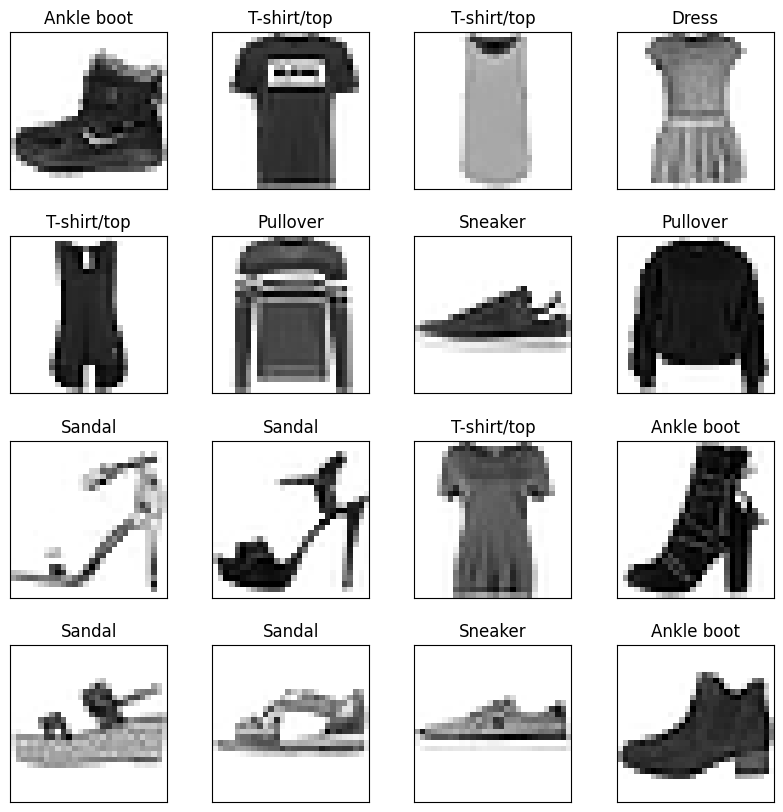

In [39]:
plt.figure(figsize=(10, 10))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.subplots_adjust(hspace=.3)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    plt.title(class_names[train_labels[i]])
plt.show()

In [41]:
X_train = train_images.reshape((train_images.shape[0], 28, 28, 1))
X_test = test_images.reshape((test_images.shape[0], 28, 28, 1))
print(X_train.shape)

(60000, 28, 28, 1)


In [43]:
tf.random.set_seed(42)
from tensorflow.keras import datasets, layers, models, losses
model = models.Sequential()
# add the first convolutional layers with 32 small-sized 3*3 filters
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
# Convolutional layer is followed by a max-pooling layer with a 2*2 filter
model.add(layers.MaxPooling2D((2, 2)))
# second convolutional layer with 64 3*3 filters
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
# third convolutional layer with 128 3*3 filters
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
#The resulting filter maps are flatten to provide features to the downstream classifier backend
model.add(layers.Flatten())
#Classifier backend 
model.add(layers.Dense(64, activation='relu'))
#output with 10 nodes demonstrating 10 classes
model.add(layers.Dense(10, activation='softmax'))

model.compile(optimizer='adam',
              loss=losses.sparse_categorical_crossentropy,
              metrics=['accuracy'])


In [45]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,114 (652.79 KB)

 Trainable params: 167,114 (652.79 KB)

 Non-trainable params: 0 (0.00 B)

In [47]:
model.fit(X_train, train_labels, validation_split=0.15, epochs=10, batch_size= 256)

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.7390 - loss: 0.7246 - val_accuracy: 0.8044 - val_loss: 0.5476
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.8428 - loss: 0.4305 - val_accuracy: 0.8466 - val_loss: 0.4194
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.8662 - loss: 0.3691 - val_accuracy: 0.8633 - val_loss: 0.3750
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.8793 - loss: 0.3313 - val_accuracy: 0.8678 - val_loss: 0.3650
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.8882 - loss: 0.3055 - val_accuracy: 0.8743 - val_loss: 0.3446
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.8967 - loss: 0.2848 - val_accuracy: 0.8873 - val_loss: 0.3171
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9031 - loss: 0.2671 - val_accuracy: 0.8928 - val_loss: 0.2998
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9087 - loss: 0.2520 - val_accu

In [48]:
test_loss, test_acc = model.evaluate(X_test, test_labels, verbose=2)
print('Accuracy on test set: ',test_acc)

313/313 - 1s - 2ms/step - accuracy: 0.8960 - loss: 0.2868
Accuracy on test set:  0.8960000276565552


In [57]:
predictions = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [61]:
print(predictions[0])

[4.1965816e-07 7.2249745e-10 1.1662270e-09 5.6446597e-10 1.6568252e-09
 2.6290020e-04 4.4391086e-08 2.9805871e-03 2.6600931e-06 9.9675345e-01]


In [63]:
import numpy as np

print('Predicted label for the first test sample: ', np.argmax(predictions[0]))

Predicted label for the first test sample:  9


In [65]:
print('True label for the first test sample: ', test_labels[0])

True label for the first test sample:  9


In [67]:
def plot_image_prediction(i, images, predictions, labels, class_names):
    plt.subplot(1,2,1)
    plt.imshow(images[i], cmap=plt.cm.binary)
    prediction = np.argmax(predictions[i])
    color = 'blue' if prediction == labels[i] else 'red'
    plt.title(f"{class_names[labels[i]]} (predicted {class_names[prediction]})", color=color)
    plt.subplot(1,2,2)
    plt.grid(False)
    plt.xticks(range(10))
    plot = plt.bar(range(10), predictions[i], color="#777777")
    plt.ylim([0, 1])
    plot[prediction].set_color('red')
    plot[labels[i]].set_color('blue')
    plt.show()

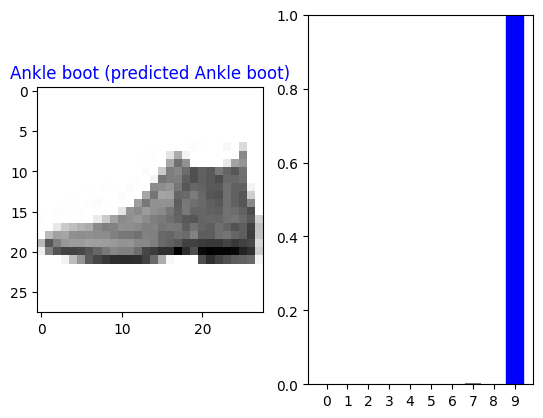

In [69]:
plot_image_prediction(0, test_images, predictions, test_labels, class_names)

In [71]:
model.layers[2].get_weights()[0].shape

(3, 3, 32, 64)

In [73]:
filters, _ = model.layers[2].get_weights()
f_min, f_max = filters.min(), filters.max()
filters = (filters - f_min) / (f_max-f_min)


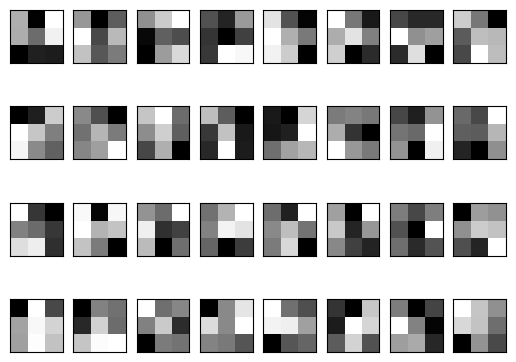

In [81]:
n_filters = 32
for i in range(n_filters):
  filter = filters[:, :, :, i]
  plt.subplot(4, 8, i+1)
  plt.xticks([])
  plt.yticks([])
  plt.imshow(filter[:, :, 0], cmap='gray')

plt.show()


In [83]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
n_small = 500
X_train = X_train[:n_small]
train_labels = train_labels[:n_small]
print(X_train.shape)

(500, 28, 28, 1)


In [85]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(32, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

In [87]:
model.compile(optimizer='adam',
               loss=losses.sparse_categorical_crossentropy,
               metrics=['accuracy'])

In [89]:
model.fit(X_train, train_labels, validation_data=(X_test, test_labels), epochs=20, batch_size=40)

Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.3180 - loss: 1.9098 - val_accuracy: 0.4571 - val_loss: 1.3976
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.6280 - loss: 1.0844 - val_accuracy: 0.6585 - val_loss: 0.9891
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.7280 - loss: 0.7957 - val_accuracy: 0.7090 - val_loss: 0.8804
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.7640 - loss: 0.6606 - val_accuracy: 0.6829 - val_loss: 0.9021
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.7880 - loss: 0.5925 - val_accuracy: 0.7062 - val_loss: 0.9328
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.7860 - loss: 0.6271 - val_accuracy: 0.7416 - val_loss: 0.6819
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.8100 - loss: 0.5429 - val_accuracy: 0.7418 - val_loss: 0.6737
Epoch 8/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.8560 - loss: 0.4111 - val_accuracy: 0.7735 - v

In [91]:
test_loss, test_acc = model.evaluate(X_test, test_labels, verbose=2)
print('Accuracy on test set:', test_acc)

313/313 - 1s - 2ms/step - accuracy: 0.7902 - loss: 0.7954
Accuracy on test set: 0.7901999950408936


In [93]:
datagen = ImageDataGenerator(height_shift_range=3,
                              horizontal_flip=True
                              )

In [95]:
model_aug = tf.keras.models.clone_model(model)

In [97]:
model_aug.compile(optimizer='adam',
               loss=losses.sparse_categorical_crossentropy,
               metrics=['accuracy'])

In [99]:
train_generator = datagen.flow(X_train, train_labels, seed=42, batch_size=40)

model_aug.fit(train_generator, epochs=50, validation_data=(X_test, test_labels))

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.2500 - loss: 2.0946 - val_accuracy: 0.3831 - val_loss: 1.7242
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.4320 - loss: 1.5683 - val_accuracy: 0.4984 - val_loss: 1.3267
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.5980 - loss: 1.1865 - val_accuracy: 0.5814 - val_loss: 1.1112
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.6640 - loss: 0.9314 - val_accuracy: 0.6610 - val_loss: 0.9229
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.6900 - loss: 0.8683 - val_accuracy: 0.7192 - val_loss: 0.9487
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.7320 - loss: 0.8290 - val_accuracy: 0.7152 - val_loss: 0.9147
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.7160 - loss: 0.8169 - val_accuracy: 0.7270 - val_loss: 0.8192
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.7800 - loss: 0.6910 - val_accuracy: 0.7476 - v

In [101]:
test_loss, test_acc = model_aug.evaluate(X_test, test_labels, verbose=2)
print('Accuracy on test set: ',test_acc)

313/313 - 1s - 2ms/step - accuracy: 0.7603 - loss: 0.9631
Accuracy on test set:  0.7602999806404114
